# 02 - Training

Three models :

| Mode | `USE_LORA` | `FREEZE_ENCODERS` | Trainable params |
|---|---|---|---|
| Full fine tune | `False` | `False` | ~197 M |
| Frozen encoders (baseline) | `False` | `True` | ~1 M |
| LoRA | `True` | `False` | ~1.5 M |

In [ ]:
import sys, os
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from vqa import config as C
C.checkEnv()
C.makeDirs()
C.showConfig()

python   : 3.11.15
executable : D:\ProgramFiles\Anaconda\envs\vqaProject\python.exe

torch          2.5.1+cu121  ok
transformers   4.55.4       ok
datasets       3.6.0        ok
peft           0.14.0       ok

torch build    : 2.5.1+cu121
cuda available : True
gpu            : NVIDIA GeForce RTX 4060 Laptop GPU
vram           : 8.6 GB

Environment looks fine
Folder tree ready under : D:\IIIT B\PersonalProjects\VQALateFusion
Root           : D:\IIIT B\PersonalProjects\VQALateFusion
Device         : cuda:0
Total images   : 5000  (train 3650 / val 675 / test 675)
Answer space   : top-1000 + <unk>
Batch / Epochs : 32 / 5
fp16           : True


### Run configuration

In [ ]:
MODE = "lora"   # "lora" | "frozen" | "full"

In [ ]:
#----------------------------------------------------------------------------------------<Run flags>----------------------||
if MODE == "lora":        #Parameter efficient fine tuning
    USE_LORA        = True
    FREEZE_ENCODERS = False
elif MODE == "frozen":    #Frozen encoders, MLP head only
    USE_LORA        = False
    FREEZE_ENCODERS = True
elif MODE == "full":      #Full fine tune, heaviest on VRAM
    USE_LORA        = False
    FREEZE_ENCODERS = False
else:
    raise ValueError(f"Unknown MODE : {MODE}")

USE_WANDB       = False    #wandb dashboard enable

#----------------------------------------------------------------------------------------<Quick run overrides>------------||
C.SUBSET_N   = None    #e.g. 2000 for a smoke test, None for the full split
C.EPOCHS     = 5
C.BATCH_SIZE = 32
C.EVAL_STEPS = 250

runDir = C.runDir(useLoRA=USE_LORA, frozen=FREEZE_ENCODERS)
runName = runDir.name
print(f"Run : {runName} -> {runDir}")

Run : withLoRA -> D:\IIIT B\PersonalProjects\VQALateFusion\outputs\withLoRA


In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import time
import json
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from vqa import dataProc as D
from vqa import model as M
from vqa import metrics as Me
from vqa import train as T

print(f"Device : {C.DEVICE}")

Device : cuda:0


In [ ]:
#----------------------------------------------------------------------------------------<Optional wandb>-----------------||
if USE_WANDB:
    import wandb
    wandb.init(
        project="VQA LateFusion",
        name=runName,
        config={
            "architecture" : "VQA Latefusion",
            "mode"         : runName,
            "epochs"       : C.EPOCHS,
            "batchSize"    : C.BATCH_SIZE,
            "topK"         : C.TOP_K_ANSWERS,
        },
    )

### Data

In [ ]:
answerSpace = D.loadAnswerSpace()
print(f"Answer space size : {len(answerSpace)}")
print(answerSpace[:10])

Answer space size : 1001
['<unk>', '0', '1', '10', '100', '100 feet', '10:26', '11', '118', '11:20']


In [ ]:
dataset = D.loadSplits(answerSpace)
dataset

train  : 19521 rows | 9.65% mapped to <unk>
test   : 3477 rows | 14.18% mapped to <unk>


DatasetDict({
    train: Dataset({
        features: ['image_id', 'image_name', 'question_id', 'question_val', 'answer_val', 'answers', 'question_type', 'answer_type', 'label'],
        num_rows: 19521
    })
    test: Dataset({
        features: ['image_id', 'image_name', 'question_id', 'question_val', 'answer_val', 'answers', 'question_type', 'answer_type', 'label'],
        num_rows: 3477
    })
})

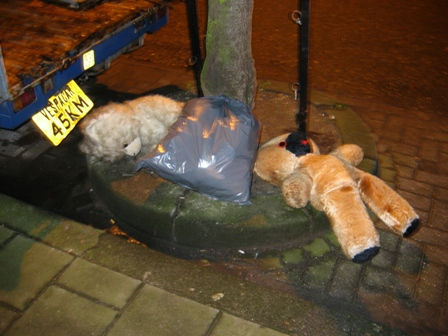

Question:	 What is inside the garbage bag?
Answer:		 trash (Label: 910)
Decoded:	 trash


In [ ]:
#----------------------------------------------------------------------------------------<To cross check samples>---------||
from PIL import Image
from IPython.display import display

def getSample(train=True, id=None):
    data = dataset["train"] if train else dataset["test"]
    id   = id if id is not None else np.random.randint(len(data))
    display(Image.open(C.IMAGE_DIR / data[id]["image_name"]))

    print("Question:\t", data[id]["question_val"])
    print("Answer:\t\t", data[id]["answer_val"], "(Label: {0})".format(data[id]["label"]))
    print("Decoded:\t", answerSpace[data[id]["label"]])

getSample() #Train

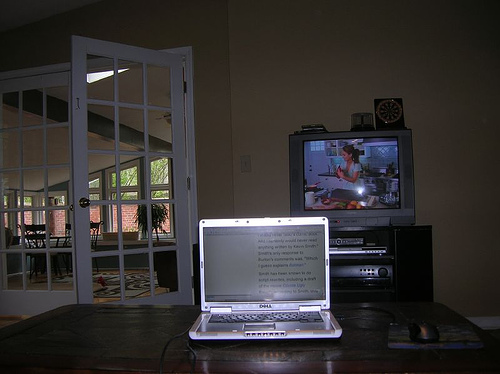

Question:	 What show are they looking at?
Answer:		 cooking (Label: 273)
Decoded:	 cooking


In [ ]:
getSample(False) #Val

### Model

Late fusion architecture :
* Textual Encoder - BERT base (`bert-base-uncased`)
* Visual Encoder - ViT base (`google/vit-base-patch16-224-in21k`)
* Concatenated pooler outputs -> Linear(1536, 512) -> ReLU -> Dropout -> classifier

In [ ]:
fdProcessor, vqaModel = M.declareModels(
    nLabels        = len(answerSpace),
    useLoRA        = USE_LORA,
    freezeEncoders = FREEZE_ENCODERS,
)

Collator reading images from : D:\IIIT B\PersonalProjects\VQALateFusion\Dataset\images224
Image path                   : lean float32
trainable params: 1,300,457 || all params: 197,171,945 || trainable%: 0.6596


In [ ]:
#----------------------------------------------------------------------------------------<Collator smoke test>------------||
batch = fdProcessor([dataset["train"][i] for i in range(4)])
for key, value in batch.items():
    print(f"{key:16} {tuple(value.shape)}")

with torch.no_grad():
    out = vqaModel(**{k: v.to(C.DEVICE) for k, v in batch.items()})
print("logits :", tuple(out["logits"].shape), "| loss :", float(out["loss"]))

input_ids        (4, 24)
token_type_ids   (4, 24)
attention_mask   (4, 24)
pixel_values     (4, 3, 224, 224)
labels           (4,)
logits : (4, 1001) | loss : 6.754894256591797


### Pipeline benchmark

In [ ]:
T.benchmarkPipeline(dataset, fdProcessor, vqaModel)

data prep   :    225.1 ms / batch
gpu step    :    203.6 ms / batch
ratio       :     1.11x

With 4 worker(s), estimated GPU utilisation : 100%

Compute bound, the pipeline is keeping up.


(225.0847475869315, 203.56311116899764)

### Metrics

`vqa` is the official VQA accuracy : an answer scores `min(matches / 3, 1)` against the 10 human answers

In [ ]:
#----------------------------------------------------------------------------------------<Human answers for scoring>------||
evalAnswers = [json.loads(a) for a in dataset["test"]["answers"]]
print(f"{len(evalAnswers)} eval rows | sample : {evalAnswers[0]}")

evalPerformance, metricsData = Me.makeEvalPerformance(
    answerSpace = answerSpace,
    evalAnswers = evalAnswers,
    useWandb    = USE_WANDB,
)

3477 eval rows | sample : ['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no']


### Training

In [ ]:
args = T.buildArgs(
    outDir    = runDir / "checkpoints",
    epochs    = C.EPOCHS,
    batchSize = C.BATCH_SIZE,
    evalSteps = C.EVAL_STEPS,
)
args

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=4,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=2,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=250,
eval_strategy=IntervalStrategy.STEPS,
eval_use_gather_object=False,
fp

In [ ]:
trainer, trainMetrics, evalMetrics, TTT = T.trainModel(
    dataset, args, fdProcessor, vqaModel, evalPerformance
)

Step,Training Loss,Validation Loss,Vqa,Acc,F1,Prec,Recall
250,5.243600,4.001615,0.259419,0.197872,0.001406,0.001062,0.002516
500,4.389800,3.927866,0.258077,0.196146,0.001360,0.000955,0.002458
750,4.275300,3.887552,0.256255,0.191257,0.001356,0.001001,0.002430
1000,4.255500,3.868526,0.260953,0.201611,0.000944,0.001026,0.002490
1250,4.215700,3.848485,0.251270,0.187230,0.001327,0.000933,0.002371
1500,4.225000,3.842920,0.254434,0.188956,0.001331,0.000926,0.002375



TrainOutput(global_step=1530, training_loss=4.427121345669615, metrics={'train_runtime': 1276.9595, 'train_samples_per_second': 76.435, 'train_steps_per_second': 1.198, 'total_flos': 0.0, 'train_loss': 4.427121345669615, 'epoch': 5.0})

{'eval_loss': 3.8685264587402344, 'eval_vqa': 0.2609529287700124, 'eval_acc': 0.2016105838366408, 'eval_f1': 0.0009435335666566178, 'eval_prec': 0.001026129634047897, 'eval_recall': 0.002489850637662696, 'eval_runtime': 90.6136, 'eval_samples_per_second': 38.372, 'eval_steps_per_second': 1.203, 'epoch': 5.0}

Time taken for training : 00 hrs 22 mins 48 seconds


Figure saved -> D:\IIIT B\PersonalProjects\VQALateFusion\report\figures\frozenEncoders_metrics.png


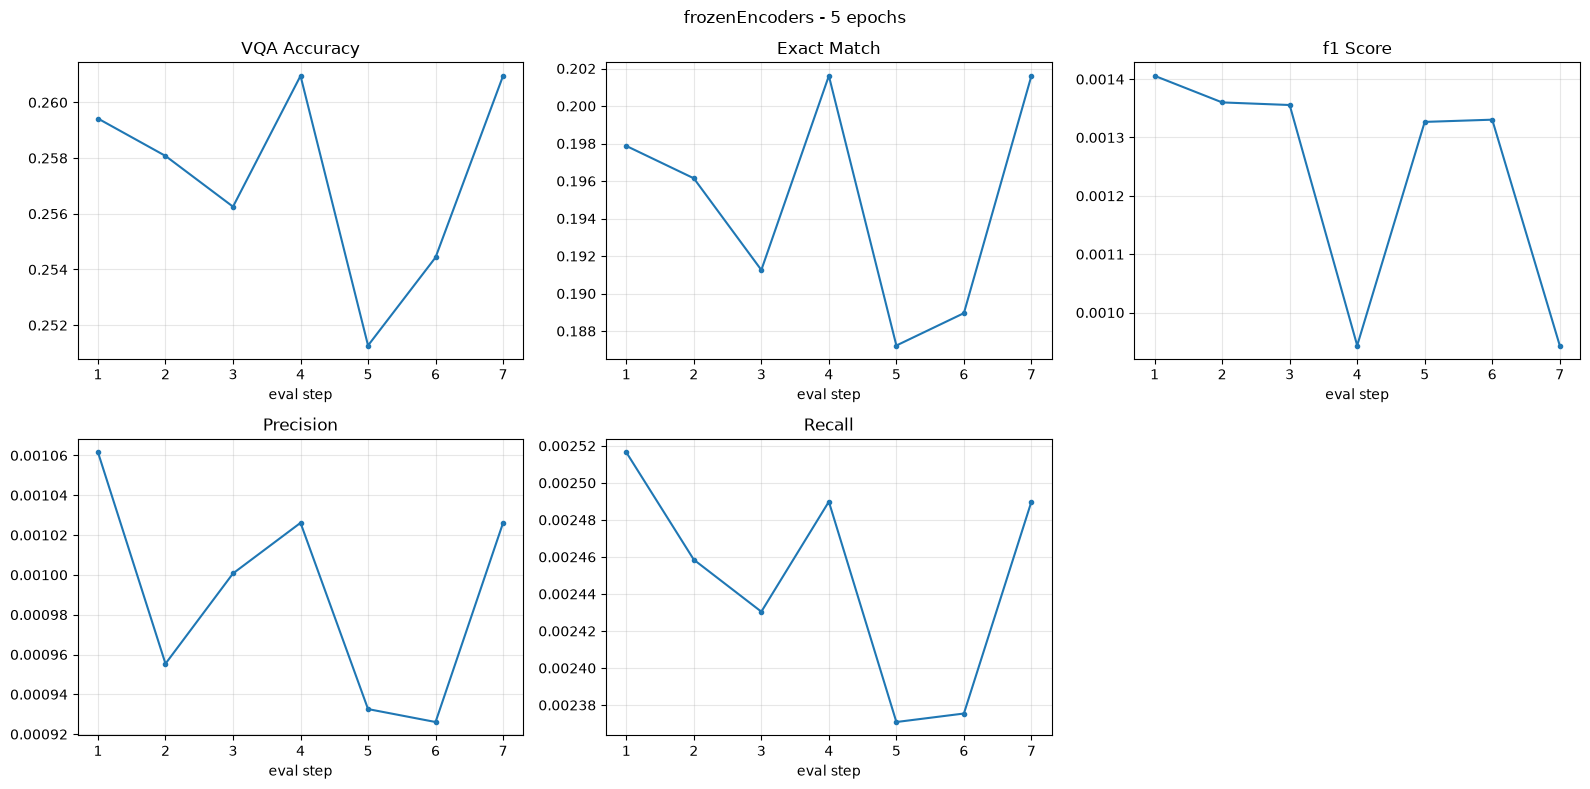

In [ ]:
Me.pltDiag(metricsData, title=f"{runName} - {C.EPOCHS} epochs",
           savePath=C.FIGURE_DIR / f"{runName}_metrics.png")

### Saving

LoRA runs save the adapter (~40 MB). Full runs save a `state_dict` plus a small `modelConfig.json` describing how to rebuild the class.


In [ ]:
saved = M.saveModel(
    trainer.model,
    outDir         = runDir / "final",
    nLabels        = len(answerSpace),
    useLoRA        = USE_LORA,
    freezeEncoders = FREEZE_ENCODERS,
)

Me.saveMetrics(metricsData, runDir / "metricsData.json")
T.saveRun(runDir, runName, trainMetrics, evalMetrics, TTT, extra={"answerSpaceSize": len(answerSpace)})

State dict saved -> D:\IIIT B\PersonalProjects\VQALateFusion\outputs\frozenEncoders\final\vqaModel.pt
Metrics saved -> D:\IIIT B\PersonalProjects\VQALateFusion\outputs\frozenEncoders\metricsData.json
Run record saved -> D:\IIIT B\PersonalProjects\VQALateFusion\outputs\frozenEncoders\runRecord.json


WindowsPath('D:/IIIT B/PersonalProjects/VQALateFusion/outputs/frozenEncoders/runRecord.json')

In [ ]:
if USE_WANDB:
    wandb.finish()

Switch the `MODE` based on the requirement